In [2]:
import numpy as np

input_data = np.load('initial_data/function_8/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.107284, 0.230012, 0.005809, 0.110406, 0.944752, 0.761346, 0.292029, 0.513328],   # week 1
    [0.001554, 0.874702, 0.057194, 0.944468, 0.772538, 0.226518, 0.257570, 0.752127]    # week 2
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (40, 8)
After: (42, 8)
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [3]:
output_data = np.load('initial_data/function_8/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    9.8491858885566,    # week 1
    8.7242298801731     # week 2
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (40,)
After: (42,)
[7.3987211  7.00522736 8.45948162 8.28400781 8.60611679 8.54174792
 7.32743458 7.29987205 7.95787474 5.59219339 7.85454099 6.79198578
 8.97655402 7.3790829  9.598482   8.15998319 7.13162397 6.76796253
 7.43374407 9.01307515 7.31089382 5.84106731 9.14163949 8.81755844
 6.45194313 8.83074505 9.34427428 6.88784639 8.04221254 7.69236805
 7.92375877 8.42175924 8.2780624  7.11345716 6.40258841 8.47293632
 7.97768459 7.46087219 7.43659353 9.18300525 9.84918589 8.72422988]


In [4]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [5]:
# Outputs span extreme ranges, so fit SVR in log|y| space
log_y = np.log(np.abs(output_data))

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(input_data)

print(f"log|y| range: [{log_y.min():.1f}, {log_y.max():.1f}]")
print(f"Negative outputs: {(output_data < 0).sum()} / {len(output_data)}")

log|y| range: [1.7, 2.3]
Negative outputs: 0 / 42


In [6]:
svr = SVR(kernel='rbf', C=100.0, epsilon=0.5, gamma='scale')
svr.fit(X_scaled, log_y)

log_y_pred = svr.predict(X_scaled)
print(f"In-sample MSE (log space): {mean_squared_error(log_y, log_y_pred):.4f}")
print(f"In-sample R²  (log space): {r2_score(log_y, log_y_pred):.4f}")


In-sample MSE (log space): 0.0192
In-sample R²  (log space): -0.1679


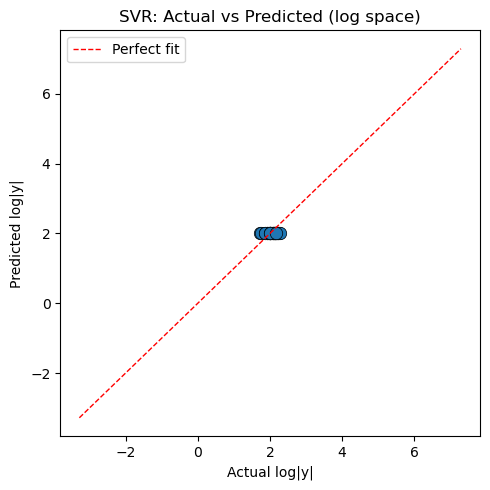

In [7]:
from scipy.stats import norm
plt.figure(figsize=(5, 5))
plt.scatter(log_y, log_y_pred, edgecolors='black', linewidths=0.5, s=80)
lims = [log_y.min() - 5, log_y.max() + 5]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
plt.xlabel('Actual log|y|')
plt.ylabel('Predicted log|y|')
plt.title('SVR: Actual vs Predicted (log space)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
query = np.array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]])
log_pred = svr.predict(scaler_X.transform(query))[0]

actual_output = 8.798300000000001
actual_log    = np.log(np.abs(actual_output))

pred_output   = np.exp(log_pred)
abs_error     = np.abs(pred_output - actual_output)
rel_error     = abs_error / np.abs(actual_output) * 100

print(f"Query point:           {query[0]}")
print(f"Predicted log|output|: {log_pred:.4f}")
print(f"Actual    log|output|: {actual_log:.4f}")
print(f"Predicted |output|:    {pred_output:.4e}")
print(f"Actual    |output|:    {actual_output:.4e}")
print(f"Absolute error:        {abs_error:.4e}")
print(f"Relative error:        {rel_error:.2f}%")

Query point:           [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Predicted log|output|: 2.0044
Actual    log|output|: 2.1746
Predicted |output|:    7.4215e+00
Actual    |output|:    8.7983e+00
Absolute error:        1.3768e+00
Relative error:        15.65%
